In [ ]:
import pandas as pd

df1 = pd.read_csv(r"C:\Users\Rahwa.B\Downloads\data\benin-malanville.csv")
df2 = pd.read_csv(r"C:\Users\Rahwa.B\Downloads\data\sierraleone-bumbuna.csv")
df3 = pd.read_csv(r"C:\Users\Rahwa.B\Downloads\data\togo-dapaong_qc.csv")
df_all = pd.concat([df1, df2, df3], ignore_index=True)

df1.describe()
df2.describe()
df3.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


In [16]:
df_all.isna().sum()


Timestamp              0
GHI                    0
DNI                    0
DHI                    0
ModA                   0
ModB                   0
Tamb                   0
RH                     0
WS                     0
WSgust                 0
WSstdev                0
WD                     0
WDstdev                0
BP                     0
Cleaning               0
Precipitation          0
TModA                  0
TModB                  0
Comments         1576800
dtype: int64

In [17]:
#list any column with >5% nulls.

null_percent = df_all.isnull().mean() * 100
cols_with_nulls = null_percent[null_percent > 5]
print(cols_with_nulls)

Comments    100.0
dtype: float64


In [58]:

# List of columns to inspect
columns_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

missing_values = df_all[columns_to_check].isnull().sum()

#Outlier detection using IQR
outliers1 = {}
for col in columns_to_check:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df1[col] < (Q1 - 1.5 * IQR)) | (df1[col] > (Q3 + 1.5 * IQR))
    outliers1[col] = df1[col][outlier_mask].count()
    
outliers2 = {}
for col in columns_to_check:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df2[col] < (Q1 - 1.5 * IQR)) | (df2[col] > (Q3 + 1.5 * IQR))
    outliers2[col] = df2[col][outlier_mask].count()
    
outliers3 = {}
for col in columns_to_check:
    Q1 = df3[col].quantile(0.25)
    Q3 = df3[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df3[col] < (Q1 - 1.5 * IQR)) | (df3[col] > (Q3 + 1.5 * IQR))
    outliers3[col] = df3[col][outlier_mask].count()
    

#Check for Incorrect entries (e.g., negative values for irradiance and wind speed)
invalid_values = {}
for col in ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']:
    invalid_values[col] = (df_all[col] < 0).sum()

# Print results
print("Missing Values:\n", missing_values, "\n")
print("Outliers Detected in Dataset 1:\n", outliers1, "\n")
print("Outliers Detected in Dataset 2:\n", outliers2, "\n")
print("Outliers Detected in Dataset 3:\n", outliers3, "\n")

print("Physically Incorrect Entries (Negatives):\n", invalid_values)


Missing Values:
 GHI       1576800
DNI       1576800
DHI       1576800
ModA      1576800
ModB      1576800
WS        1576800
WSgust    1576800
dtype: int64 

Outliers Detected in Dataset 1:
 {'GHI': np.int64(145), 'DNI': np.int64(15196), 'DHI': np.int64(8733), 'ModA': np.int64(98), 'ModB': np.int64(240), 'WS': np.int64(6717), 'WSgust': np.int64(5368)} 

Outliers Detected in Dataset 2:
 {'GHI': np.int64(15853), 'DNI': np.int64(101688), 'DHI': np.int64(4407), 'ModA': np.int64(21017), 'ModB': np.int64(20613), 'WS': np.int64(3169), 'WSgust': np.int64(3665)} 

Outliers Detected in Dataset 3:
 {'GHI': np.int64(1303), 'DNI': np.int64(50586), 'DHI': np.int64(7905), 'ModA': np.int64(1237), 'ModB': np.int64(1537), 'WS': np.int64(8708), 'WSgust': np.int64(7377)} 

Physically Incorrect Entries (Negatives):
 {'GHI': np.int64(0), 'DNI': np.int64(0), 'DHI': np.int64(0), 'ModA': np.int64(0), 'ModB': np.int64(0), 'WS': np.int64(0), 'WSgust': np.int64(0)}


In [ ]:
# Columns for Z-score computation
cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

means = df_all[cols].mean()
stds = df_all[cols].std(ddof=0)  # ddof=0 uses population standard deviation

z_scores = (df_all[cols] - means) / stds

outlier_rows = (z_scores.abs() > 3).any(axis=1)
flagged_outliers = df_all[outlier_rows]

print(f"Number of flagged outlier rows: {flagged_outliers.shape[0]}")

Number of flagged outlier rows: 28679


In [ ]:
# Handle the outliers entries
def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

irradiance_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
{'GHI': (0), 'DNI': (0), 'DHI': (161), 'ModA': (7841), 'ModB': (10119), 'WS': (15501), 'WSgust': (30004)}

df1 = remove_outliers_iqr(df1, irradiance_cols)
df2 = remove_outliers_iqr(df2, irradiance_cols)
df3 = remove_outliers_iqr(df3, irradiance_cols)

In [41]:
key_columns = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

for col in key_columns:
    median_value = df_all[col].median()
    df_all[col] = df_all[col].fillna(median_value)

print(df_all[key_columns].isnull().sum())

GHI       0
DNI       0
DHI       0
ModA      0
ModB      0
WS        0
WSgust    0
dtype: int64


In [59]:
# Handle the negative values

invalid_columns = ['GHI']

for col in invalid_columns:
    df_all[col] = df_all[col].mask(df_all[col] < 0)
    
for col in invalid_columns:
    median_val = df_all[col].median()
    df_all[col]= df_all[col].fillna(median_val)

C:\Users\Rahwa.B\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [55]:

# List of columns to inspect
columns_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

missing_values = df_all[columns_to_check].isnull().sum()

#Outlier detection using IQR
outliers = {}
for col in columns_to_check:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_mask = (df_all[col] < (Q1 - 1.5 * IQR)) | (df_all[col] > (Q3 + 1.5 * IQR))
    outliers[col] = df_all[col][outlier_mask].count()

#Check for Incorrect entries (e.g., negative values for irradiance and wind speed)
invalid_values = {}
for col in ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']:
    invalid_values[col] = (df_all[col] < 0).sum()

# Print results
print("Missing Values:\n", missing_values, "\n")
print("Outliers Detected:\n", outliers, "\n")
print("Physically Incorrect Entries (Negatives):\n", invalid_values)


Missing Values:
 GHI       0
DNI       0
DHI       0
ModA      0
ModB      0
WS        0
WSgust    0
dtype: int64 

Outliers Detected:
 {'GHI': np.int64(754962), 'DNI': np.int64(176753), 'DHI': np.int64(81358), 'ModA': np.int64(7841), 'ModB': np.int64(10119), 'WS': np.int64(15501), 'WSgust': np.int64(30004)} 

Physically Incorrect Entries (Negatives):
 {'GHI': np.int64(0), 'DNI': np.int64(0), 'DHI': np.int64(0), 'ModA': np.int64(0), 'ModB': np.int64(0), 'WS': np.int64(0), 'WSgust': np.int64(0)}


In [49]:
import os

# Suppose you have a variable for country name

country1 = "Benin"  
country2 = "SierraLeone"
country3 = "Togo"

os.makedirs('data', exist_ok=True)

output_path = f'data/{country1}_clean.csv'
df1.to_csv(output_path, index=False)

output_path = f'data/{country2}_clean.csv'
df2.to_csv(output_path, index=False)

output_path = f'data/{country3}_clean.csv'
df3.to_csv(output_path, index=False)
print(f"Cleaned data exported to {output_path}")


Cleaned data exported to data/Togo_clean.csv


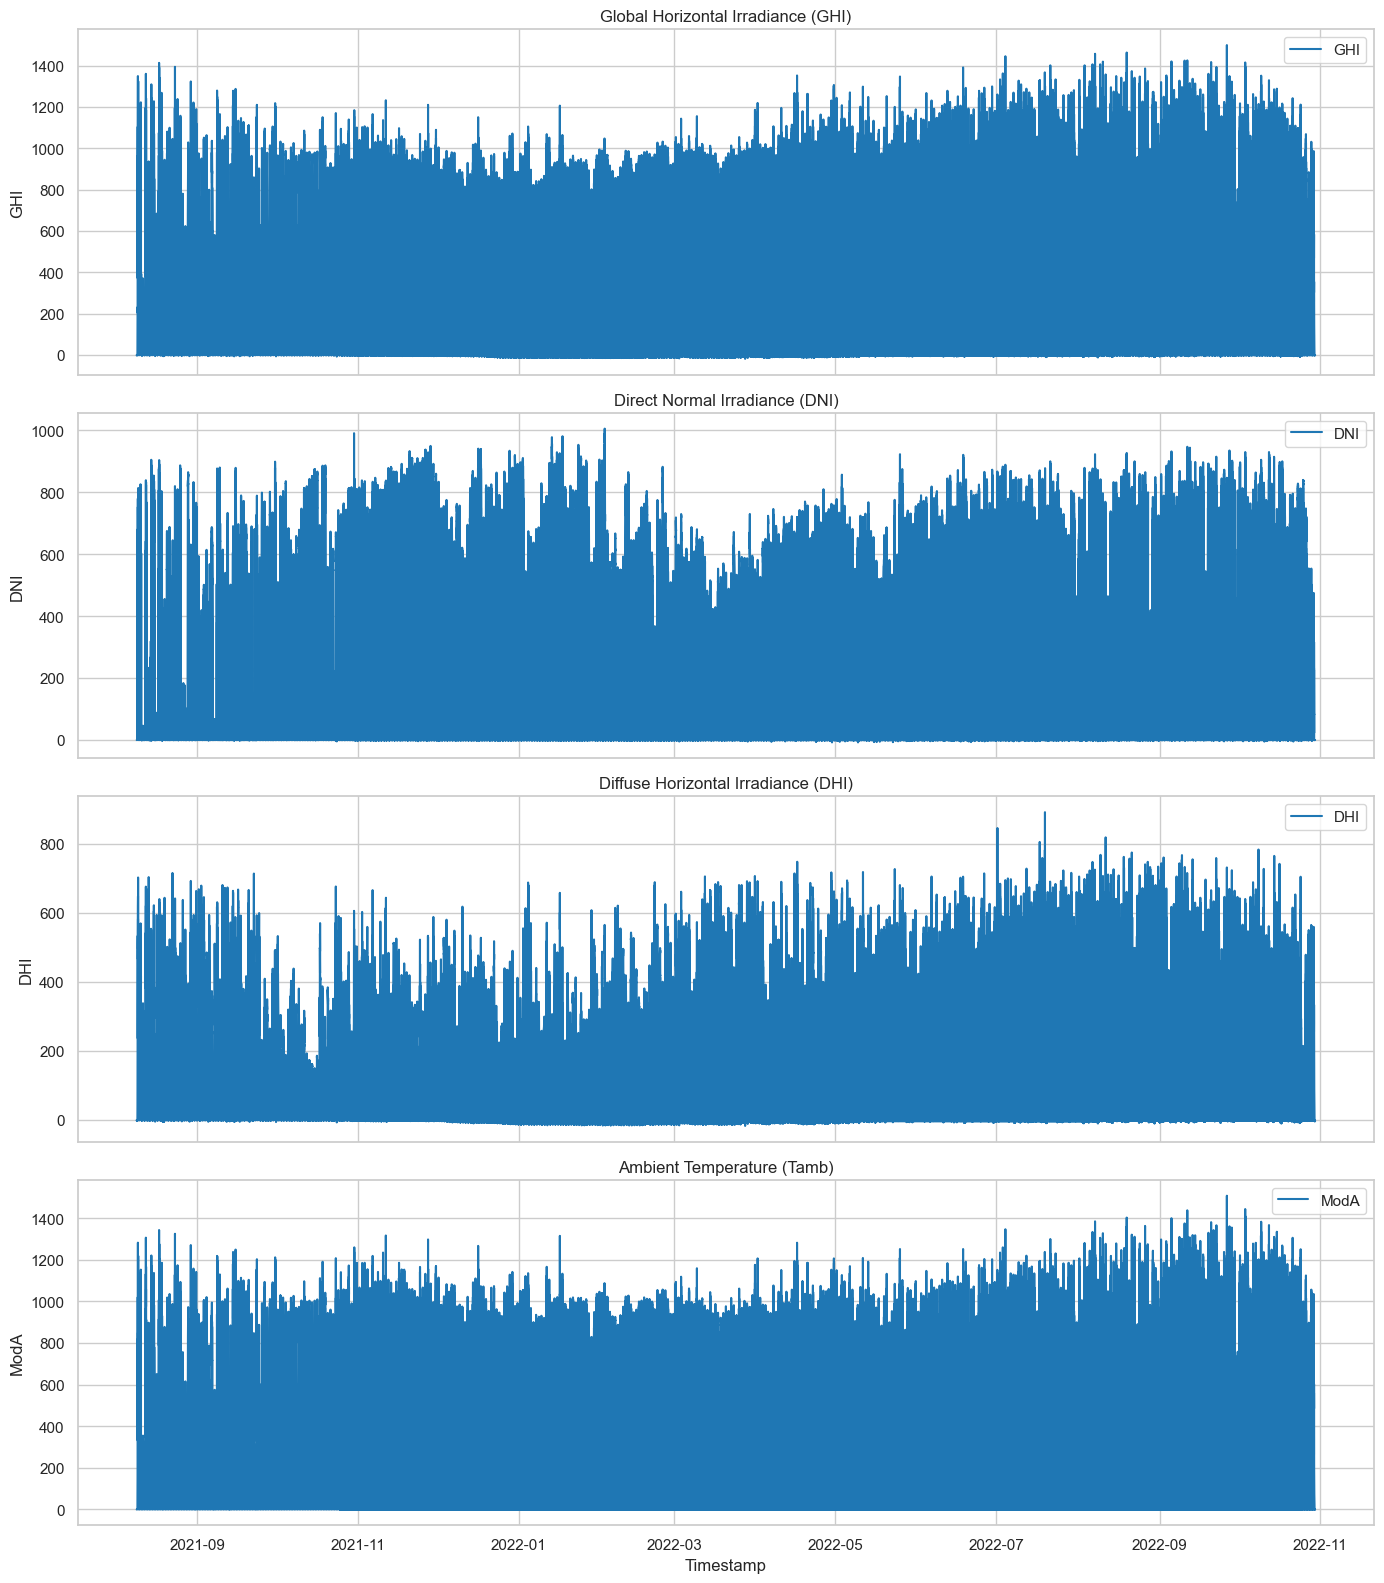

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df1 = pd.read_csv(r"C:\Users\Rahwa.B\Downloads\data\Benin_clean.csv")
df2 = pd.read_csv(r"C:\Users\Rahwa.B\Downloads\data\SierraLeone_clean.csv")
df3 = pd.read_csv(r"C:\Users\Rahwa.B\Downloads\data\Togo_clean.csv")
df_all = pd.concat([df1, df2, df3], ignore_index=True)

df_all['Timestamp'] = pd.to_datetime(df_all['Timestamp'], format='%Y-%m-%d %H:%M', errors='raise')

fig, axs = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

cols_to_plot = ['GHI', 'DNI', 'DHI', 'Tamb']
titles = ['Global Horizontal Irradiance (GHI)', 'Direct Normal Irradiance (DNI)', 
          'Diffuse Horizontal Irradiance (DHI)', 'Ambient Temperature (Tamb)']

for i, col in enumerate(cols_to_plot):
    axs[i].plot(df_all['Timestamp'], df_all[col], label=col, color='tab:blue')
    axs[i].set_title(titles[i])
    axs[i].set_ylabel(col)
    axs[i].legend()
    axs[i].grid(True)

plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()


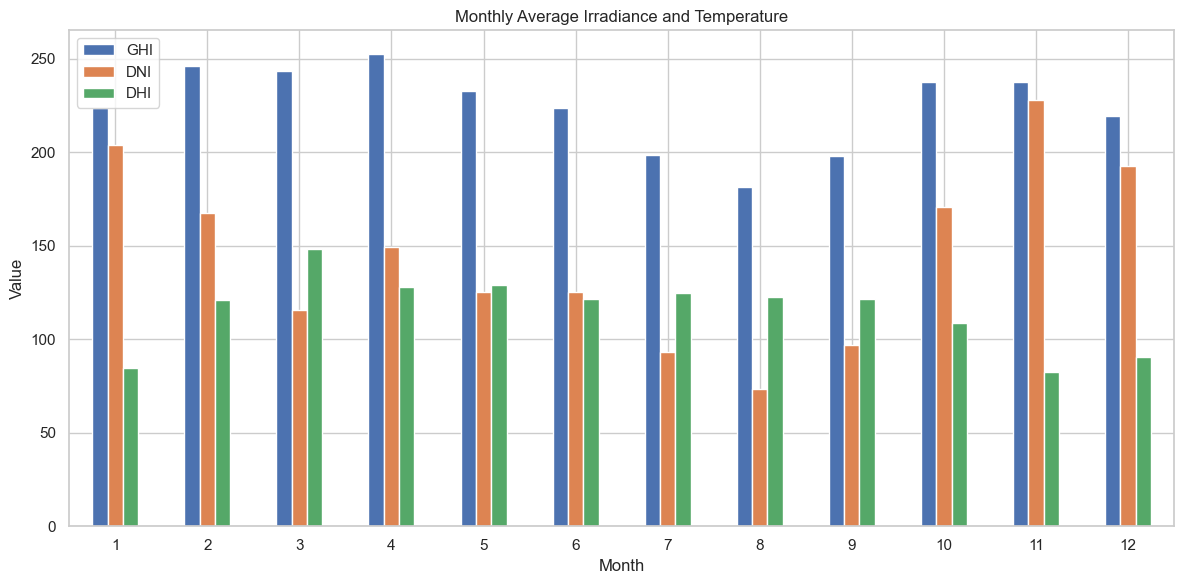

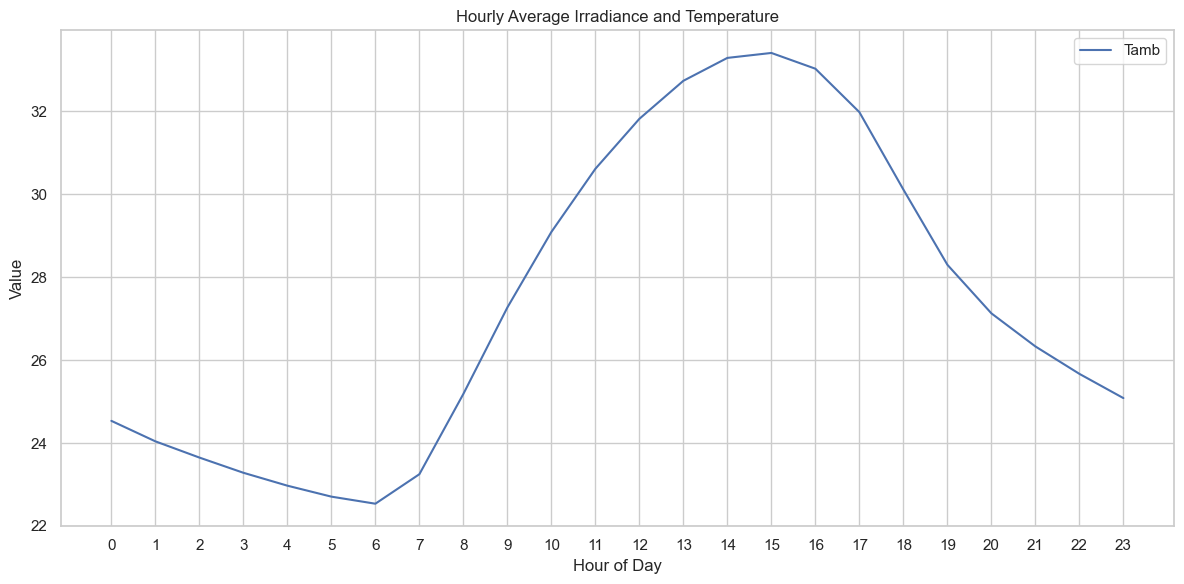

Anomaly Summary:
              Timestamp     GHI  Tamb
615 2021-08-09 10:16:00  1059.0  28.1
617 2021-08-09 10:18:00  1088.0  28.7
618 2021-08-09 10:19:00  1104.0  28.9
619 2021-08-09 10:20:00  1075.0  28.8
620 2021-08-09 10:21:00  1045.0  28.9


In [ ]:
df_all['Timestamp'] = pd.to_datetime(df_all['Timestamp'], format='%Y-%m-%d %H:%M', errors='raise')

df_all['Month'] = df_all['Timestamp'].dt.month
df_all['Hour'] = df_all['Timestamp'].dt.hour

# 1. Monthly Averages (Seasonal Trends)

monthly_avg = df_all.groupby('Month')[['GHI', 'DNI', 'DHI']].mean()

monthly_avg.plot(kind='bar', figsize=(12, 6))
plt.title('Monthly Average Irradiance')
plt.ylabel('Value')
plt.xlabel('Month')
plt.xticks(rotation=0)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 2. Hourly Averages (Daily Cycle Trends)

hourly_avg = df_all.groupby('Hour')[['Tamb']].mean()

hourly_avg.plot(figsize=(12, 6))
plt.title('Hourly Average and Temperature')
plt.ylabel('Value')
plt.xlabel('Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


# 3. Anomaly Detection (Irradiance Peaks & Temp Spikes)

ghi_threshold = df_all['GHI'].quantile(0.99)
tamb_threshold = df_all['Tamb'].quantile(0.99)

anomalies = df_all[(df_all['GHI'] > ghi_threshold) | (df_all['Tamb'] > tamb_threshold)]

print("Anomaly Summary:")
print(anomalies[['Timestamp', 'GHI', 'Tamb']].sort_values(by='Timestamp').head())


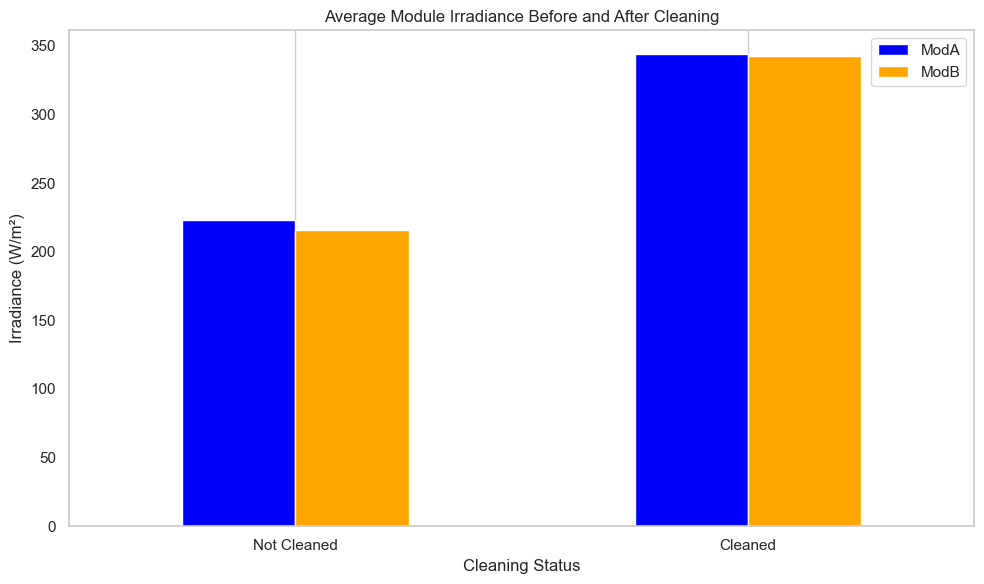

In [19]:
cleaning_group = df_all.groupby('Cleaning')[['ModA', 'ModB']].mean().rename(index={0: 'Not Cleaned', 1: 'Cleaned'})

cleaning_group.plot(kind='bar', figsize=(10,6), color=['blue', 'orange'])
plt.title('Average Module Irradiance Before and After Cleaning')
plt.ylabel('Irradiance (W/m²)')
plt.xlabel('Cleaning Status')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

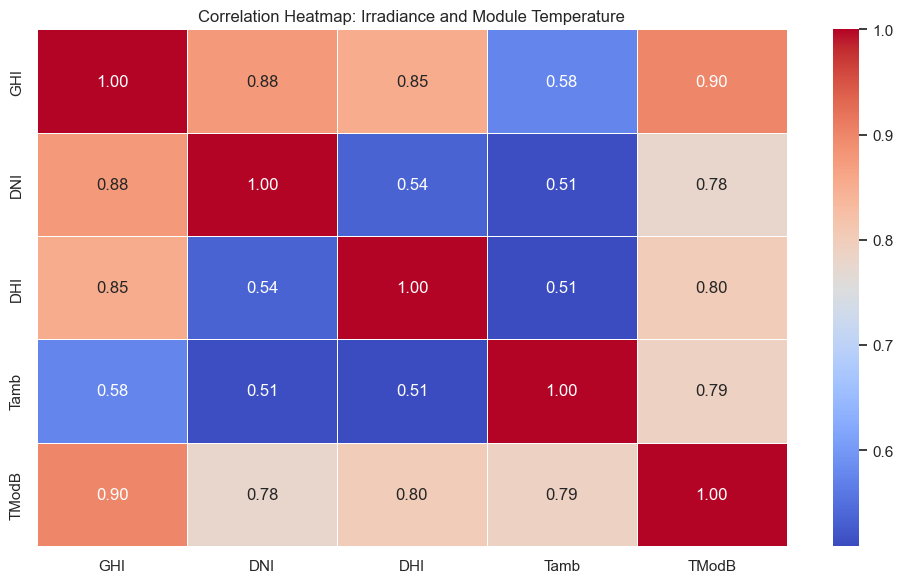

In [21]:
import seaborn as sns
corr_cols = ['GHI', 'DNI', 'DHI', 'Tamb', 'TModB']
corr_matrix =  df_all[corr_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Irradiance and Module Temperature')
plt.tight_layout()
plt.show()

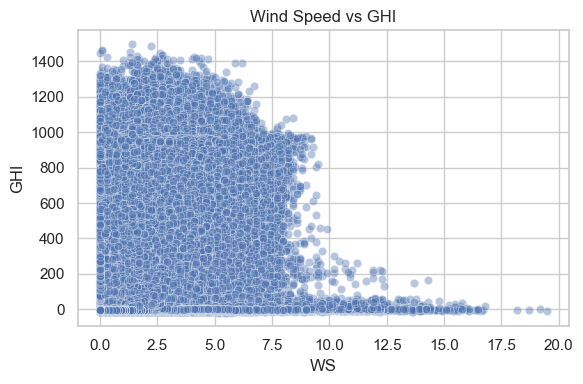

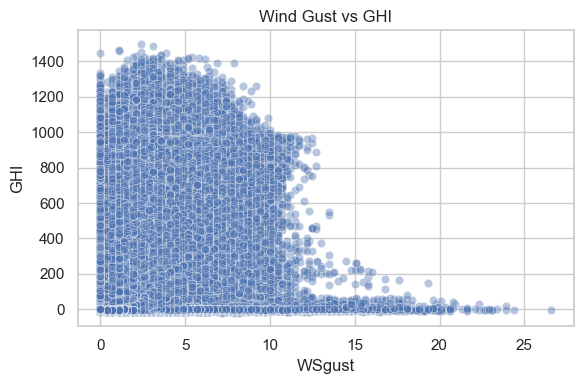

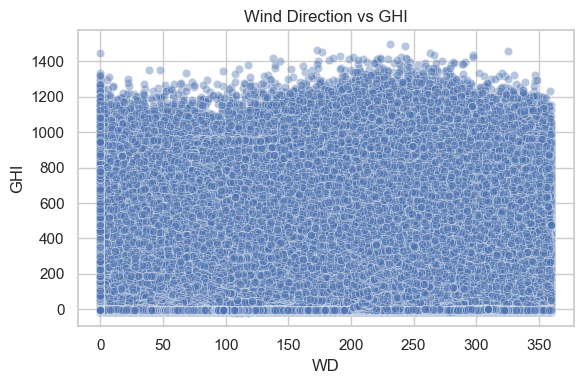

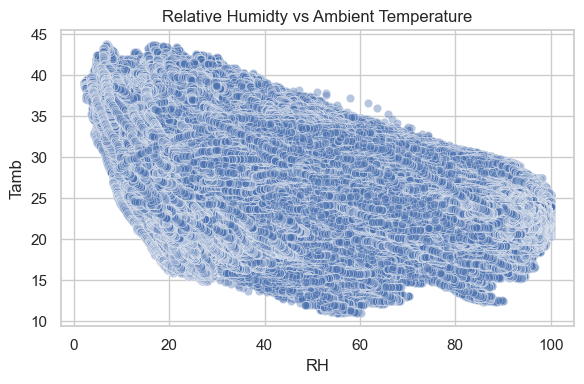

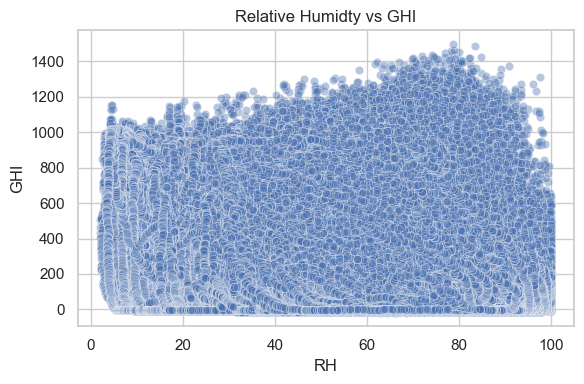

In [29]:
sns.set(style='whitegrid')

#Plot 1
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_all, x='WS', y='GHI', alpha=0.4)
plt.title('Wind Speed vs GHI')
plt.tight_layout()
plt.show()

#Plot 2
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_all, x='WSgust', y='GHI', alpha=0.4)
plt.title('Wind Gust vs GHI')
plt.tight_layout()
plt.show()

#Plot 3
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_all, x='WD', y='GHI', alpha=0.4)
plt.title('Wind Direction vs GHI')
plt.tight_layout()
plt.show()

#Plot 4
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_all, x='RH', y='Tamb', alpha=0.4)
plt.title('Relative Humidty vs Ambient Temperature')
plt.tight_layout()
plt.show()

#Plot 5
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_all, x='RH', y='GHI', alpha=0.4)
plt.title('Relative Humidty vs GHI')
plt.tight_layout()
plt.show()

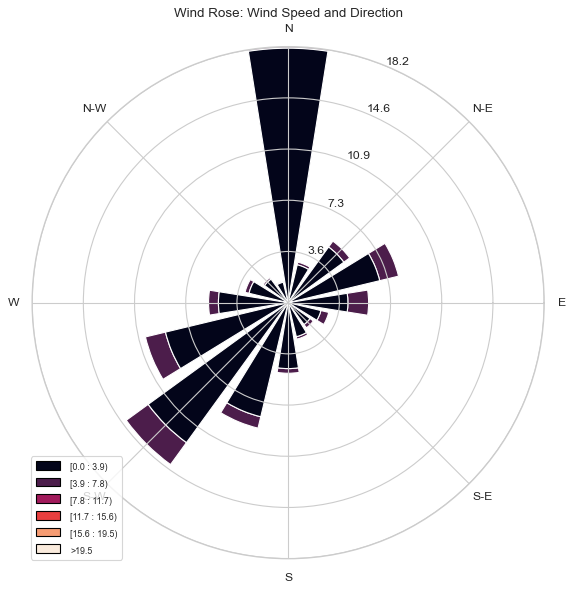

In [ ]:
from windrose import WindroseAxes

wind_data = df_all[['WS', 'WD']]

ax = WindroseAxes.from_ax()
ax.bar(wind_data['WD'], wind_data['WS'], normed=True, opening=0.8, edgecolor='white', cmap=None)
ax.set_legend()
plt.title('Wind Rose: Wind Speed and Direction')
plt.show()

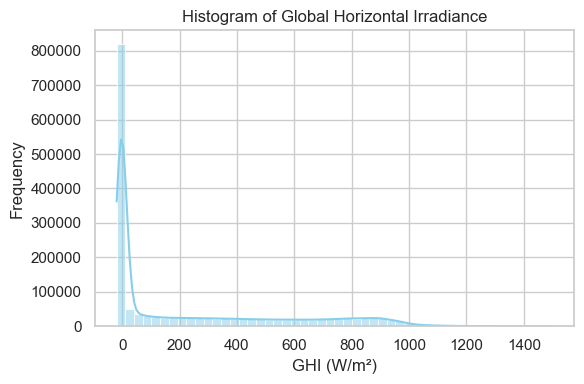

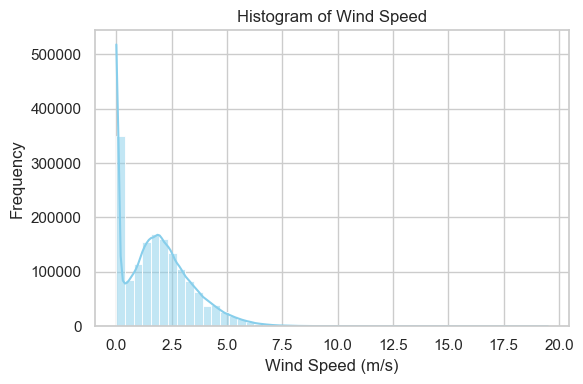

In [37]:
plt.figure(figsize=(6, 4))
sns.histplot(df_all['GHI'], bins=50, kde=True, color='skyblue')
plt.title('Histogram of Global Horizontal Irradiance')
plt.xlabel('GHI (W/m²)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(df_all['WS'], bins=50, kde=True, color='skyblue')
plt.title('Histogram of Wind Speed')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [40]:
rh_corr_tamb = df_all['RH'].corr(df_all['Tamb'])
print(f"Correlation between RH and Tamb: {rh_corr_tamb:.2f}")


Correlation between RH and Tamb: -0.51


C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_1292\3303199768.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rh_bin_summary = df_all.groupby('RH_bin')[['Tamb', 'GHI']].mean()


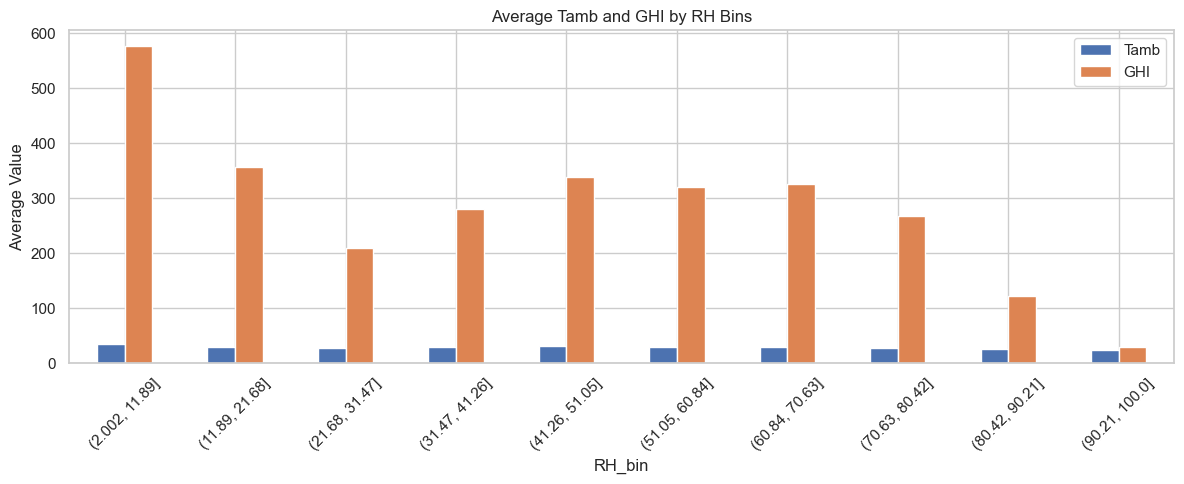

Correlation between RH and Tamb: -0.51
Correlation between RH and Tamb: -0.35


In [ ]:
#How relative humidity (RH) might influence temperature readings and solar radiation.
df_all['RH_bin'] = pd.cut(df_all['RH'], bins=10)

rh_bin_summary = df_all.groupby('RH_bin')[['Tamb', 'GHI']].mean()

rh_bin_summary.plot(kind='bar', figsize=(12, 5))
plt.title('Average Tamb and GHI by RH Bins')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rh_corr_tamb = df_all['RH'].corr(df_all['Tamb'])
rh_corr_ghi = df_all['RH'].corr(df_all['GHI'])

print(f"Correlation between RH and Tamb: {rh_corr_tamb:.2f}")
print(f"Correlation between RH and Tamb: {rh_corr_ghi:.2f}")


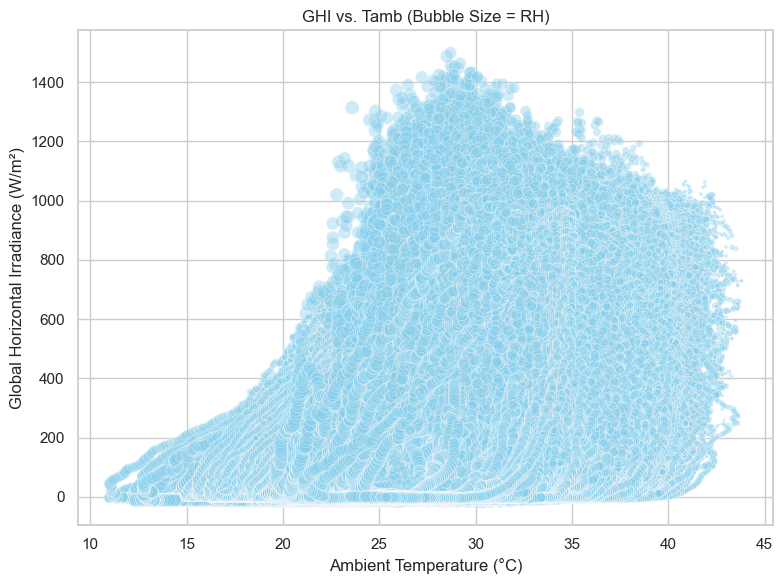

In [ ]:
#Bubble Chart

plt.figure(figsize=(8, 6))
plt.scatter(df_all['Tamb'], df_all['GHI'], s=df_all['RH'], alpha=0.4, c='skyblue', edgecolors='w', linewidth=0.5)
plt.title('GHI vs. Tamb (Bubble Size = RH)')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Global Horizontal Irradiance (W/m²)')
plt.grid(True)
plt.tight_layout()
plt.show()
